# Paper Bag Analysis – STFT, Spectral Features & Onset Timeline

Dieses Notebook lädt deine WAV-Datei und berechnet:
- STFT-Spektrogramm (dB)
- *Spectral Centroid* (Schwerpunkt)
- *Spectral Rolloff* (85% und 95%)
- *Spectral Flatness* (0..1)
- Onset-Timeline (Ereignis-Markierungen)

**Hinweise**
- Keine Subplots; jede Grafik steht separat.
- Nur Matplotlib; keine Seaborn-Abhängigkeit.
- FFT-Parameter so gewählt, dass ~75% Overlap entsteht (n_fft=2048, hop_length=512).


In [159]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf  # optional: Schreiben/Lesen von Audiodateien

print("librosa:", librosa.__version__)


librosa: 0.10.2.post1


In [161]:
# Pfad zu deiner Aufnahme (dein absoluter Pfad)
AUDIO_PATH = r"/Users/macbook/Dropbox/MDW/Lehrveranstaltungen/03 Semester 5 - 6/Lechner Music Processing/20251009 Lechner Music Processing/Papier1.wav"

SR_TARGET = None  # None = Original-Samplerate beibehalten

# STFT-Parameter (Hann, ~75% Overlap)
N_FFT = 2048
HOP_LENGTH = 512
WIN = "hann"

# Rolloff-Perzentile
ROLLOFF_PCTS = (0.85, 0.95)


In [163]:
y, sr = librosa.load(AUDIO_PATH, sr=SR_TARGET, mono=True)
duration = len(y) / sr
print(f"Geladen: {AUDIO_PATH}\nsr={sr} Hz | Dauer={duration:.2f} s | Samples={len(y)}")


Geladen: /Users/macbook/Dropbox/MDW/Lehrveranstaltungen/03 Semester 5 - 6/Lechner Music Processing/20251009 Lechner Music Processing/Papier1.wav
sr=48000 Hz | Dauer=2.15 s | Samples=103157


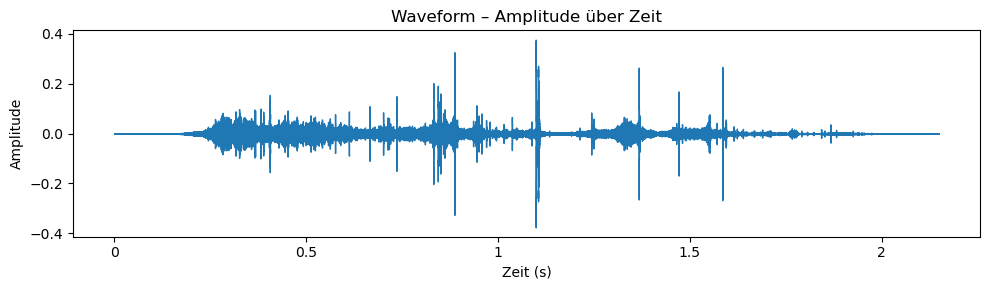

In [165]:
# --- Waveform (Amplitude über Zeit) ---
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform – Amplitude über Zeit")
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


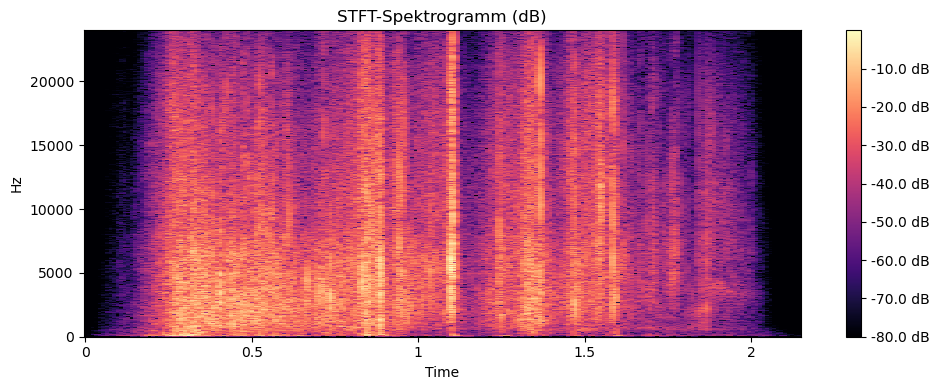

In [166]:
S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=WIN)
S_mag = np.abs(S)
S_db = librosa.amplitude_to_db(S_mag, ref=np.max)

times = librosa.times_like(S, sr=sr, hop_length=HOP_LENGTH)
freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, x_axis='time', y_axis='hz', sr=sr, hop_length=HOP_LENGTH)
plt.title('STFT-Spektrogramm (dB)')
plt.colorbar(format='%+0.1f dB')
plt.tight_layout()
plt.show()



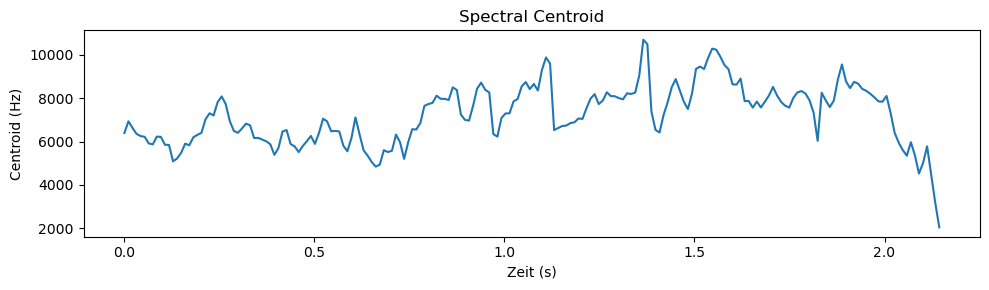

In [168]:
centroid = librosa.feature.spectral_centroid(S=S_mag, sr=sr)
t_cent = librosa.times_like(centroid, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10, 3))
plt.plot(t_cent, centroid[0])
plt.xlabel('Zeit (s)')
plt.ylabel('Centroid (Hz)')
plt.title('Spectral Centroid')
plt.tight_layout()
plt.show()


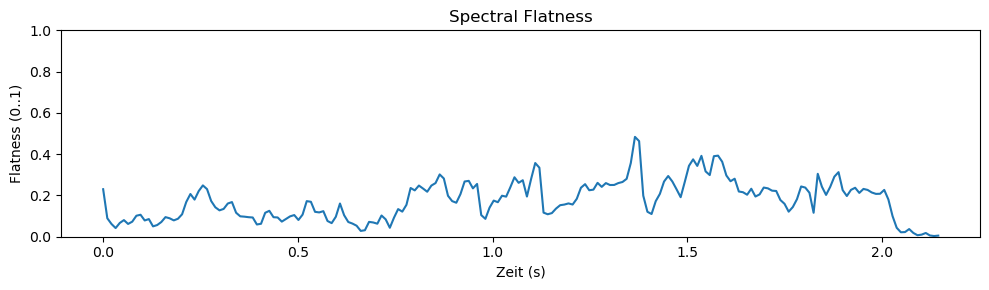

In [170]:
flatness = librosa.feature.spectral_flatness(S=S_mag)
t_flat = librosa.times_like(flatness, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10, 3))
plt.plot(t_flat, flatness[0])
plt.ylim(0, 1)
plt.xlabel('Zeit (s)')
plt.ylabel('Flatness (0..1)')
plt.title('Spectral Flatness')
plt.tight_layout()
plt.show()


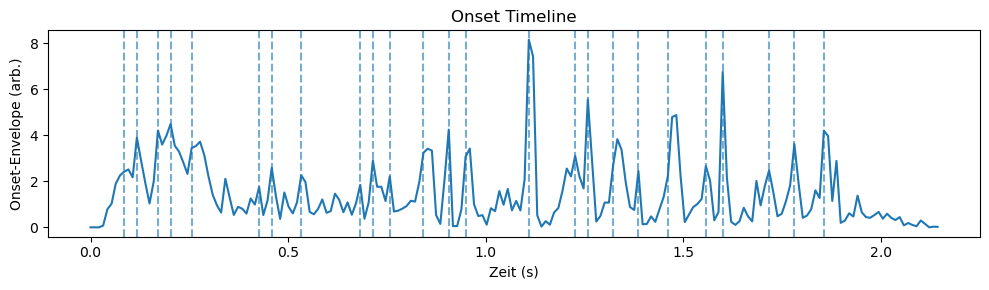

Anzahl Onsets: 25
Onset-Zeiten (s): [0.085 0.117 0.171 0.203 0.256 0.427 0.459 0.533 0.683 0.715 0.757 0.843
 0.907 0.949 1.109 1.227 1.259 1.323 1.387 1.461 1.557 1.6   1.717 1.781
 1.856]


In [172]:
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
onset_times = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, hop_length=HOP_LENGTH, units='time')
t_env = librosa.times_like(onset_env, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10, 3))
plt.plot(t_env, onset_env)
for t in onset_times:
    plt.axvline(t, linestyle='--', alpha=0.6)
plt.xlabel('Zeit (s)')
plt.ylabel('Onset-Envelope (arb.)')
plt.title('Onset Timeline')
plt.tight_layout()
plt.show()

print(f"Anzahl Onsets: {len(onset_times)}")
print("Onset-Zeiten (s):", np.round(onset_times, 3))


In [174]:
# --- CSV neben der Audio-Datei speichern (robuste Version) ---
from pathlib import Path
import csv
import numpy as np

# AUDIO_PATH (String oder Path) -> Path
AUDIO_PATH = Path(str(AUDIO_PATH))
CSV_PATH = AUDIO_PATH.parent / "paper_bag_features.csv"
print("CSV wird gespeichert nach:", CSV_PATH)

# Falls Features noch nicht existieren (z. B. Zellen in falscher Reihenfolge ausgeführt), nachrechnen:
try:
    S_mag
except NameError:
    # STFT neu berechnen (setzt y, sr, N_FFT, HOP_LENGTH, WIN voraus)
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=WIN)
    S_mag = np.abs(S)

# Centroid
try:
    centroid
    t_cent
except NameError:
    centroid = librosa.feature.spectral_centroid(S=S_mag, sr=sr)
    t_cent = librosa.times_like(centroid, sr=sr, hop_length=HOP_LENGTH)

# Flatness
try:
    flatness
except NameError:
    flatness = librosa.feature.spectral_flatness(S=S_mag)

# Rolloff-Kurven (85% & 95%)
try:
    rolloff_curves
except NameError:
    rolloff_curves = {}
    for pct in (0.85, 0.95):
        ro = librosa.feature.spectral_rolloff(S=S_mag, sr=sr, roll_percent=pct)
        rolloff_curves[pct] = (librosa.times_like(ro, sr=sr, hop_length=HOP_LENGTH), ro[0])

# --- Export ---
with open(CSV_PATH, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['time_s', 'centroid_hz', 'rolloff85_hz', 'rolloff95_hz', 'flatness_0_1'])

    ro85_t, ro85 = rolloff_curves[0.85]
    ro95_t, ro95 = rolloff_curves[0.95]

    # Frame-lange Zeitachse (identisch für Centroid/Flatness/rolloff in diesem Setup)
    T = t_cent
    L = len(T)
    for i in range(L):
        c  = float(centroid[0, i]) if i < centroid.shape[1] else ''
        r85 = float(ro85[i])       if i < len(ro85)           else ''
        r95 = float(ro95[i])       if i < len(ro95)           else ''
        fl = float(flatness[0, i]) if i < flatness.shape[1]   else ''
        w.writerow([float(T[i]), c, r85, r95, fl])

print("Export fertig. Existiert CSV?", CSV_PATH.exists())


CSV wird gespeichert nach: /Users/macbook/Dropbox/MDW/Lehrveranstaltungen/03 Semester 5 - 6/Lechner Music Processing/20251009 Lechner Music Processing/paper_bag_features.csv
Export fertig. Existiert CSV? True


In [176]:
# --- Onset-Zeiten separat speichern neben der Audio-Datei ---
from pathlib import Path
import numpy as np, csv

AUDIO_PATH = Path(str(AUDIO_PATH))
ONSETS_CSV = AUDIO_PATH.parent / "paper_bag_onsets.csv"

# sicherstellen, dass onset_times existiert; sonst berechnen
try:
    onset_times
except NameError:
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
    onset_times = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr,
                                             hop_length=HOP_LENGTH, units='time')

with open(ONSETS_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["onset_time_s"])
    for t in onset_times:
        w.writerow([float(t)])

print("Onsets gespeichert:", ONSETS_CSV, "| Anzahl:", len(onset_times))


Onsets gespeichert: /Users/macbook/Dropbox/MDW/Lehrveranstaltungen/03 Semester 5 - 6/Lechner Music Processing/20251009 Lechner Music Processing/paper_bag_onsets.csv | Anzahl: 25


In [178]:
import numpy as np

# Sicherstellen, dass S_mag, centroid, flatness, rolloff_curves existieren
try:
    S_mag
except NameError:
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=WIN)
    S_mag = np.abs(S)

# Zeit- und Frequenzachsen
times = librosa.times_like(S_mag, sr=sr, hop_length=HOP_LENGTH)
freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)

# 1) Band-Energieanteile (als Prozente) in drei „Papier-Bändern“
bands = [(700,1500), (2000,4000), (5500,8000)]
band_names = ["Körper (0.7–1.5 kHz)", "Rascheln (2–4 kHz)", "Knistern (5.5–8 kHz)"]
band_energy = []
total_energy = (S_mag**2).sum(axis=0) + 1e-12  # tiny epsilon

for (lo,hi) in bands:
    idx = np.where((freqs>=lo)&(freqs<=hi))[0]
    e = (S_mag[idx,:]**2).sum(axis=0)
    band_energy.append(e)

band_energy = np.vstack(band_energy)  # shape 3 x frames
band_share_mean = (band_energy / total_energy).mean(axis=1)  # mittlerer Anteil

# 2) Centroid / Rolloff / Flatness – Lage & Streuung
C = centroid[0]  # Hz
F = flatness[0]  # 0..1
ro85 = rolloff_curves[0.85][1]
ro95 = rolloff_curves[0.95][1]

def stats(x):
    return dict(mean=float(np.nanmean(x)),
                p10=float(np.nanpercentile(x,10)),
                p50=float(np.nanpercentile(x,50)),
                p90=float(np.nanpercentile(x,90)))

centroid_stats = stats(C)
flatness_stats = stats(F)
ro85_stats = stats(ro85)
ro95_stats = stats(ro95)

# 3) Onset-Rate & Clusterung
try:
    onset_times
except NameError:
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
    onset_times = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr,
                                             hop_length=HOP_LENGTH, units='time')

if len(onset_times)>1:
    isi = np.diff(onset_times)  # inter-onset intervals
    onset_rate_avg = 1.0 / np.mean(isi)
    isi_stats = stats(isi)
else:
    onset_rate_avg = 0.0
    isi_stats = {"mean":0,"p10":0,"p50":0,"p90":0}

print("=== Zusammenfassung ===")
print(f"Dauer: {len(y)/sr:.2f} s | sr={sr} Hz | hop={HOP_LENGTH} (~{HOP_LENGTH/sr*1000:.1f} ms/Frame)")
print("\nBandanteile (Mittel):")
for name,share in zip(band_names, band_share_mean):
    print(f"  {name}: {share*100:.1f}%")

print("\nCentroid (Hz):", centroid_stats)
print("Rolloff85 (Hz):", ro85_stats)
print("Rolloff95 (Hz):", ro95_stats)
print("Flatness (0..1):", flatness_stats)

print("\nOnsets:", len(onset_times),
      f"| mittlere Rate ≈ {onset_rate_avg:.1f}/s" if onset_rate_avg>0 else "")
print("Inter-Onset-Interval (s):", isi_stats)


=== Zusammenfassung ===
Dauer: 2.15 s | sr=48000 Hz | hop=512 (~10.7 ms/Frame)

Bandanteile (Mittel):
  Körper (0.7–1.5 kHz): 7.9%
  Rascheln (2–4 kHz): 24.8%
  Knistern (5.5–8 kHz): 15.6%

Centroid (Hz): {'mean': 7223.944855063352, 'p10': 5596.759535907866, 'p50': 7300.517507460011, 'p90': 8754.506820485247}
Rolloff85 (Hz): {'mean': 13784.846844059406, 'p10': 10856.25, 'p50': 13957.03125, 'p90': 16125.0}
Rolloff95 (Hz): {'mean': 18742.342202970296, 'p10': 16771.875, 'p50': 18925.78125, 'p90': 20435.15625}
Flatness (0..1): {'mean': 0.1754922717809677, 'p10': 0.06200975365936756, 'p50': 0.17401500791311264, 'p90': 0.28742579221725467}

Onsets: 25 | mittlere Rate ≈ 13.6/s
Inter-Onset-Interval (s): {'mean': 0.07377777777777779, 'p10': 0.03200000000000001, 'p50': 0.06400000000000006, 'p90': 0.1397333333333333}


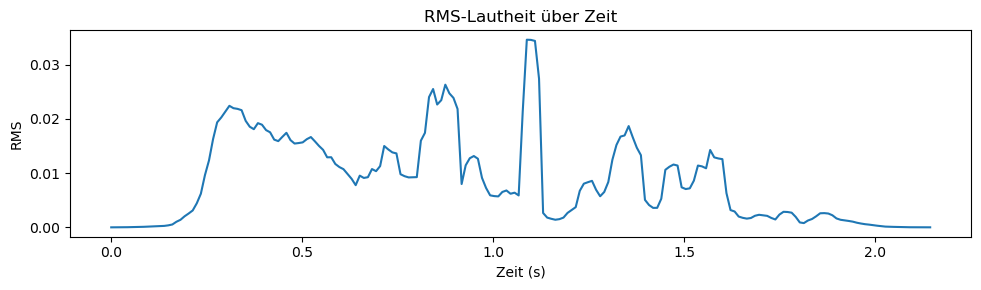

In [181]:
import numpy as np, librosa, matplotlib.pyplot as plt

rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
t_rms = librosa.times_like(rms, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10,3))
plt.plot(t_rms, rms)
plt.xlabel("Zeit (s)"); plt.ylabel("RMS")
plt.title("RMS-Lautheit über Zeit")
plt.tight_layout(); plt.show()


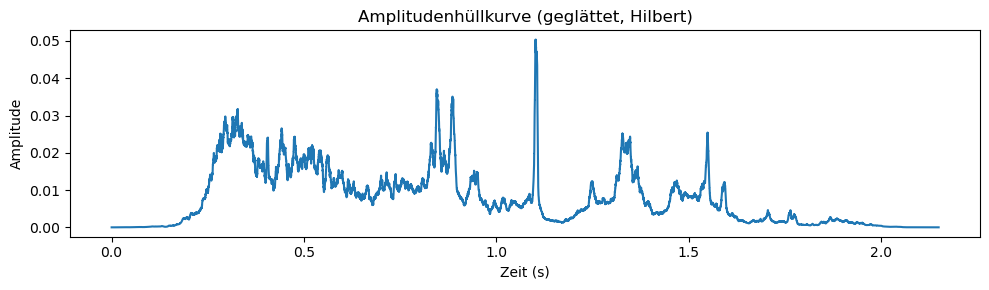

In [182]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# Analytisches Signal via SciPy-Hilbert → Betrag = Hüllkurve
analytic = sig.hilbert(y)
env = np.abs(analytic)

# Glätten (Median-Filter). Kernel MUSS ungerade sein:
kernel = 301  # ≈ 301 / 48000 s ≈ 6.3 ms bei 48 kHz
if kernel % 2 == 0:
    kernel += 1
env_smooth = sig.medfilt(env, kernel_size=kernel)

t = np.arange(len(y)) / sr
plt.figure(figsize=(10,3))
plt.plot(t, env_smooth)
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.title("Amplitudenhüllkurve (geglättet, Hilbert)")
plt.tight_layout()
plt.show()


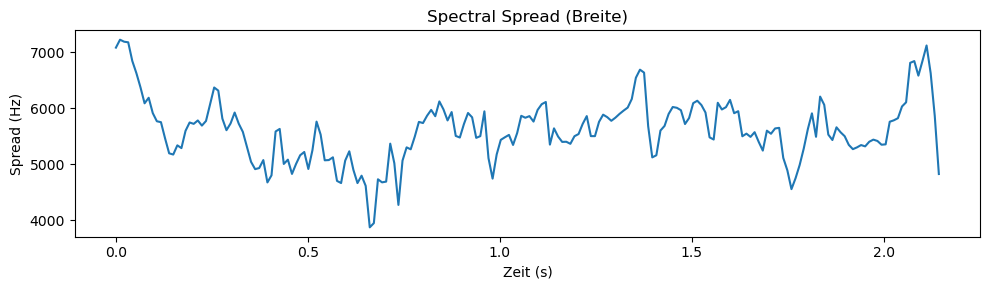

In [184]:
# sicherstellen, dass S_mag existiert
try:
    S_mag
except NameError:
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=WIN)
    S_mag = np.abs(S)

spread = librosa.feature.spectral_bandwidth(S=S_mag, sr=sr)  # = Standardabweichung um den Centroid
t_spread = librosa.times_like(spread, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10,3))
plt.plot(t_spread, spread[0])
plt.xlabel("Zeit (s)"); plt.ylabel("Spread (Hz)")
plt.title("Spectral Spread (Breite)")
plt.tight_layout(); plt.show()


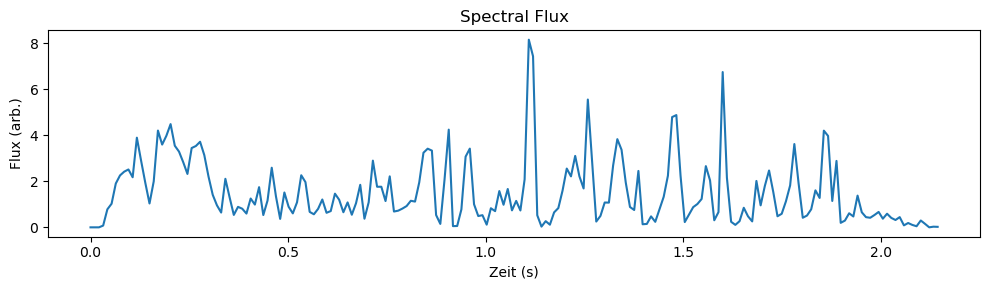

In [186]:
flux = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
t_flux = librosa.times_like(flux, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10,3))
plt.plot(t_flux, flux)
plt.xlabel("Zeit (s)"); plt.ylabel("Flux (arb.)")
plt.title("Spectral Flux")
plt.tight_layout(); plt.show()


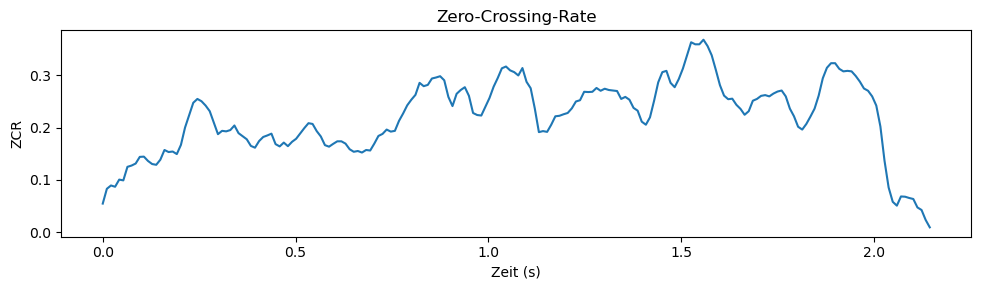

In [189]:
zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
t_zcr = librosa.times_like(zcr, sr=sr, hop_length=HOP_LENGTH)

plt.figure(figsize=(10,3))
plt.plot(t_zcr, zcr)
plt.xlabel("Zeit (s)"); plt.ylabel("ZCR")
plt.title("Zero-Crossing-Rate")
plt.tight_layout(); plt.show()


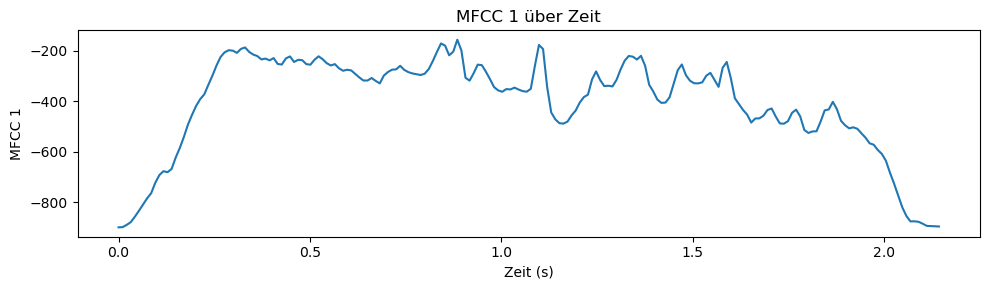

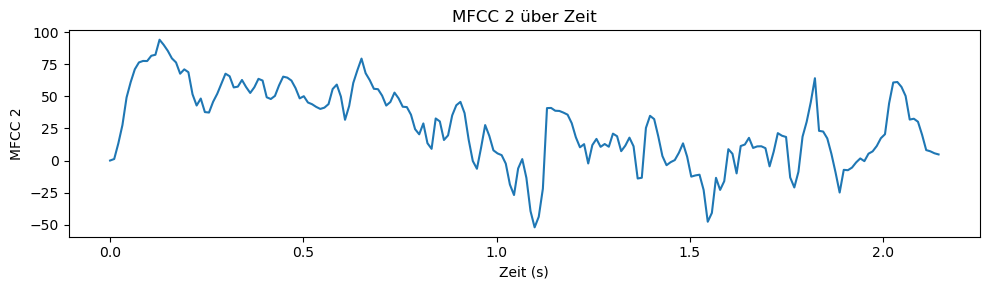

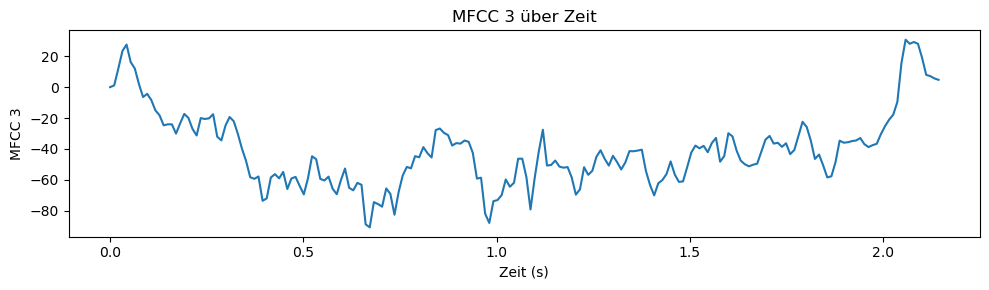

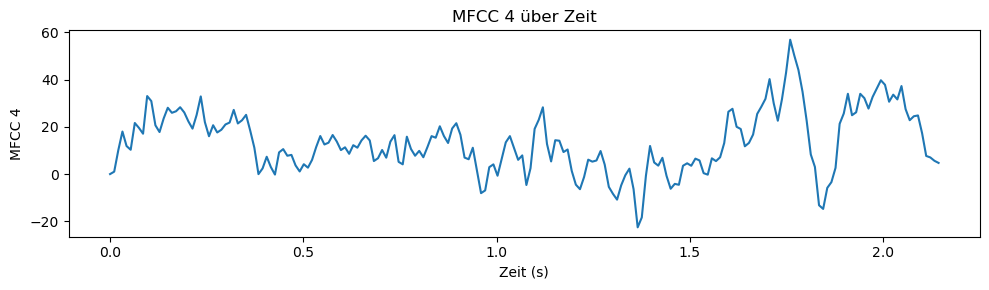

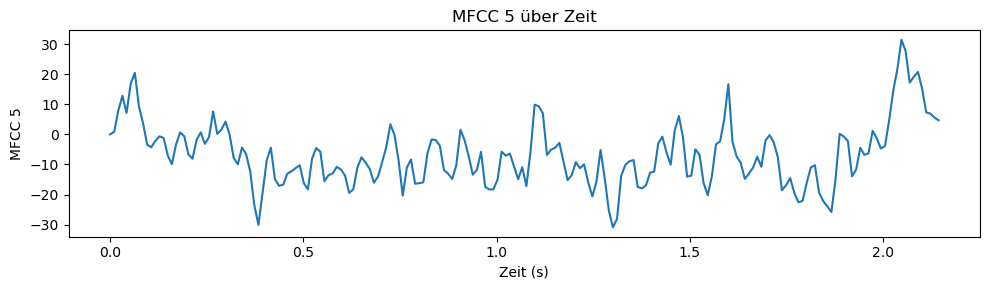

In [191]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5, n_fft=N_FFT, hop_length=HOP_LENGTH)
t_mfcc = librosa.times_like(mfcc, sr=sr, hop_length=HOP_LENGTH)

for i in range(mfcc.shape[0]):
    plt.figure(figsize=(10,3))
    plt.plot(t_mfcc, mfcc[i])
    plt.xlabel("Zeit (s)"); plt.ylabel(f"MFCC {i+1}")
    plt.title(f"MFCC {i+1} über Zeit")
    plt.tight_layout(); plt.show()


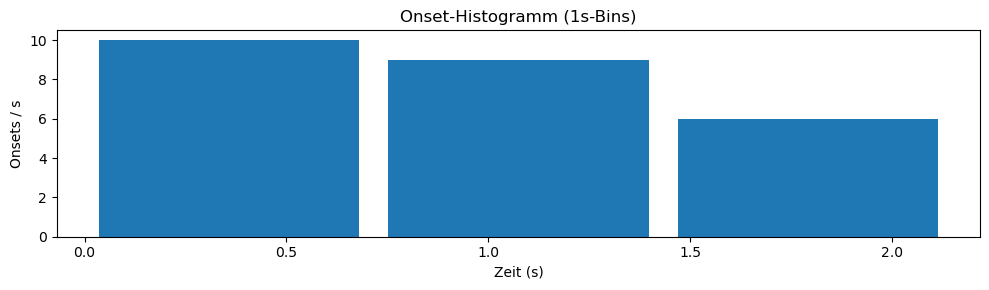

In [192]:
plt.figure(figsize=(10,3))
# bars zentriert auf die 1s-Intervalle
width = np.diff(edges).mean() * 0.9  # ~0.9 Sek. breit
plt.bar(centers, hist, width=width, align="center")
plt.xlabel("Zeit (s)")
plt.ylabel("Onsets / s")
plt.title("Onset-Histogramm (1s-Bins)")
plt.tight_layout()
plt.show()


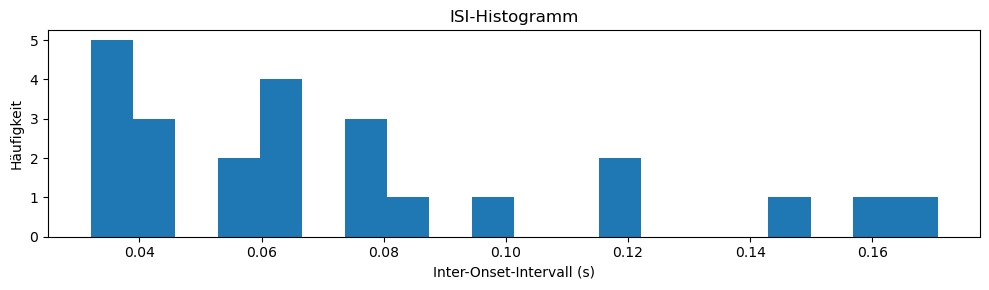

In [194]:
import numpy as np
if len(onset_times) > 1:
    isi = np.diff(onset_times)
else:
    isi = np.array([])

plt.figure(figsize=(10,3))
if isi.size:
    plt.hist(isi, bins=20)
plt.xlabel("Inter-Onset-Intervall (s)"); plt.ylabel("Häufigkeit")
plt.title("ISI-Histogramm")
plt.tight_layout(); plt.show()


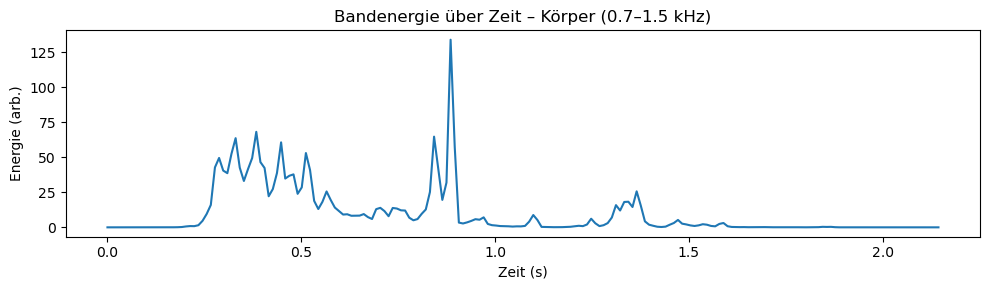

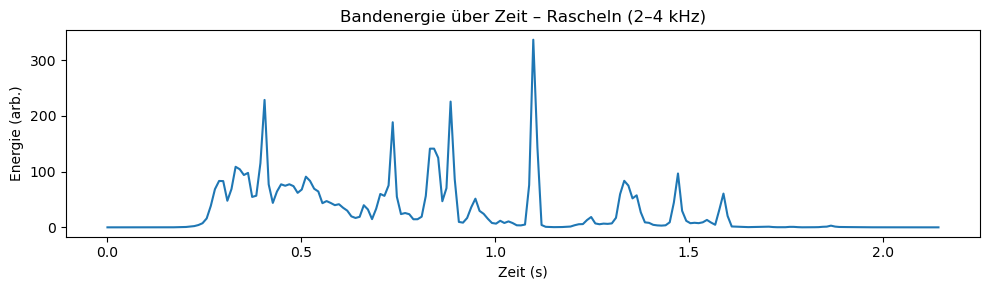

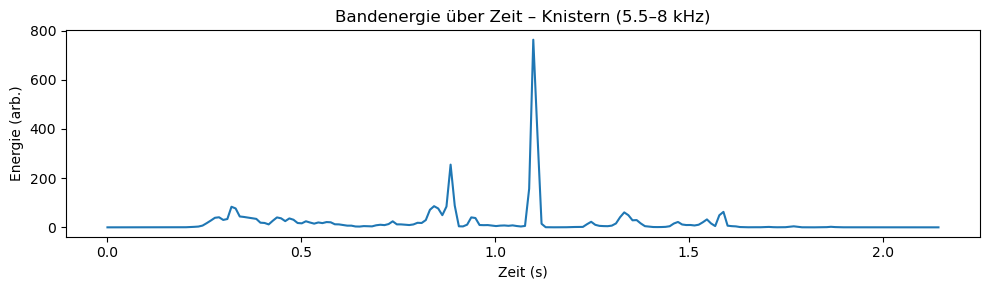

In [197]:
# Frequenzachsen und Magnitudenenergy
freqs = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
E = S_mag**2
t_frames = librosa.times_like(S_mag, sr=sr, hop_length=HOP_LENGTH)

bands = [(700,1500), (2000,4000), (5500,8000)]
labels = ["Körper (0.7–1.5 kHz)", "Rascheln (2–4 kHz)", "Knistern (5.5–8 kHz)"]

for (lo, hi), lab in zip(bands, labels):
    idx = np.where((freqs>=lo)&(freqs<=hi))[0]
    band_env = E[idx,:].sum(axis=0)
    plt.figure(figsize=(10,3))
    plt.plot(t_frames, band_env)
    plt.xlabel("Zeit (s)"); plt.ylabel("Energie (arb.)")
    plt.title(f"Bandenergie über Zeit – {lab}")
    plt.tight_layout(); plt.show()


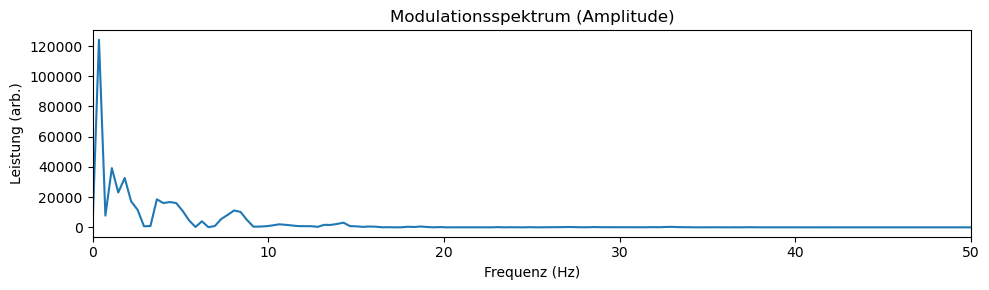

In [199]:
# hochauflösende Hüllkurve: RMS interpolieren auf Samples
t_rms = librosa.times_like(rms, sr=sr, hop_length=HOP_LENGTH)
rms_interp = np.interp(np.arange(len(y))/sr, t_rms, rms)

# FFT des zentrierten RMS-Signals
x = rms_interp - np.mean(rms_interp)
N = 2**int(np.ceil(np.log2(len(x))))
X = np.fft.rfft(x, n=N)
f = np.fft.rfftfreq(N, d=1/sr)
P = (np.abs(X)**2)

plt.figure(figsize=(10,3))
plt.plot(f, P)
plt.xlim(0, 50)  # AM-Rate bis 50 Hz interessant
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Leistung (arb.)")
plt.title("Modulationsspektrum (Amplitude)")
plt.tight_layout(); plt.show()


In [201]:
# Variante 1
!pip install --quiet pyloudnorm


In [202]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "pyloudnorm"])


0

Integrated Loudness (LUFS): -34.59


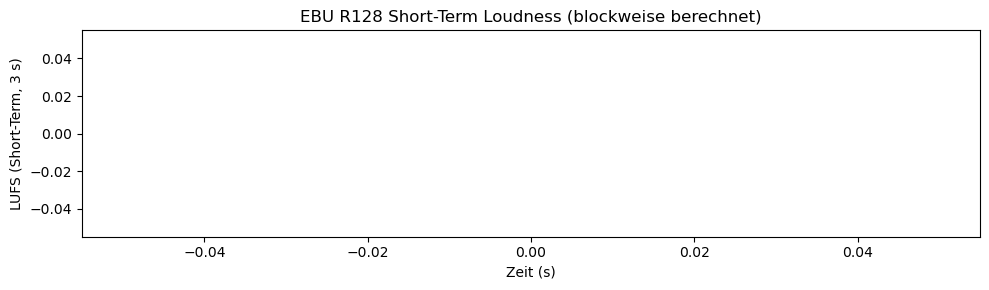

In [205]:
import numpy as np
import pyloudnorm as pyln
import matplotlib.pyplot as plt

meter = pyln.Meter(sr)  # EBU R128-konform

# Integrierte Lautheit (ein Wert für das ganze File)
lufs_integrated = meter.integrated_loudness(y.astype(float))
print("Integrated Loudness (LUFS):", round(lufs_integrated, 2))

# --- Short-Term: 3 s Fenster, 1 s Hop ---
win_s = 3.0
hop_s = 1.0
win = int(round(win_s * sr))
hop = int(round(hop_s * sr))

lufs_st_vals = []
lufs_st_times = []

i = 0
y_float = y.astype(float)
while i + win <= len(y_float):
    seg = y_float[i:i+win]
    lufs = meter.integrated_loudness(seg)
    lufs_st_vals.append(lufs)
    # Zeitstempel = Fenstermitte
    lufs_st_times.append((i + win/2) / sr)
    i += hop

lufs_st_vals = np.array(lufs_st_vals)
lufs_st_times = np.array(lufs_st_times)

plt.figure(figsize=(10,3))
plt.plot(lufs_st_times, lufs_st_vals)
plt.xlabel("Zeit (s)")
plt.ylabel("LUFS (Short-Term, 3 s)")
plt.title("EBU R128 Short-Term Loudness (blockweise berechnet)")
plt.tight_layout()
plt.show()


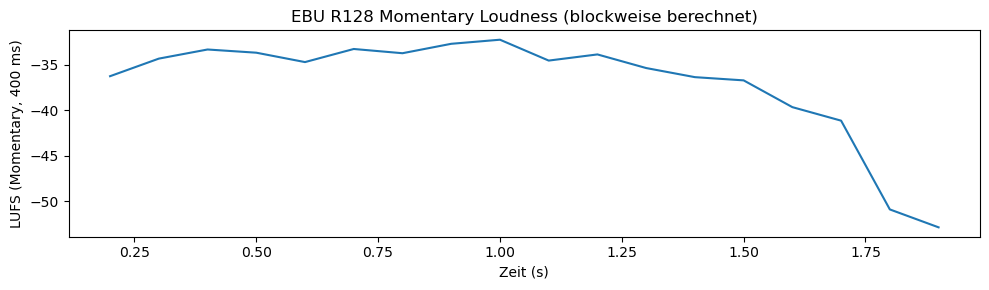

In [207]:
# --- Momentary: 0.4 s Fenster, 0.1 s Hop ---
win_s = 0.4
hop_s = 0.1
win = int(round(win_s * sr))
hop = int(round(hop_s * sr))

lufs_m_vals = []
lufs_m_times = []

i = 0
while i + win <= len(y_float):
    seg = y_float[i:i+win]
    lufs = meter.integrated_loudness(seg)
    lufs_m_vals.append(lufs)
    lufs_m_times.append((i + win/2) / sr)
    i += hop

lufs_m_vals = np.array(lufs_m_vals)
lufs_m_times = np.array(lufs_m_times)

plt.figure(figsize=(10,3))
plt.plot(lufs_m_times, lufs_m_vals)
plt.xlabel("Zeit (s)")
plt.ylabel("LUFS (Momentary, 400 ms)")
plt.title("EBU R128 Momentary Loudness (blockweise berechnet)")
plt.tight_layout()
plt.show()


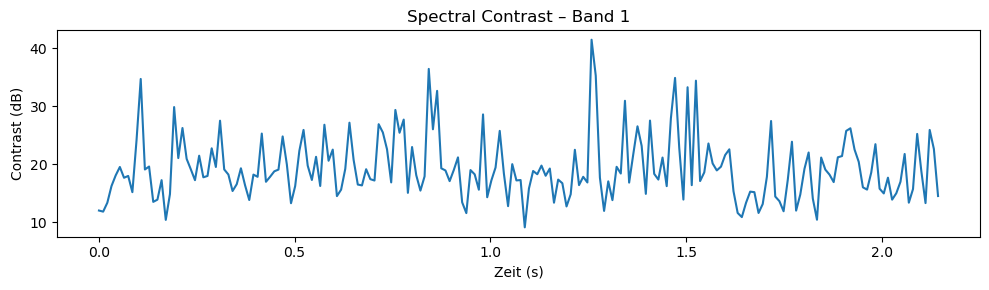

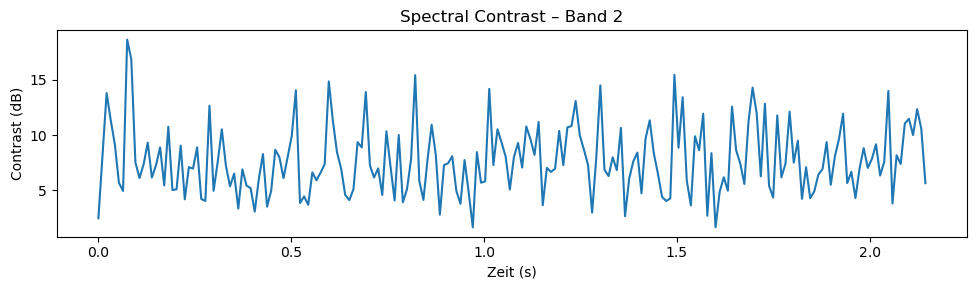

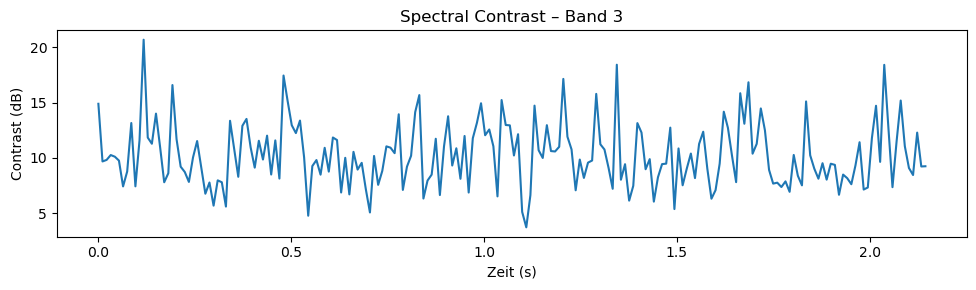

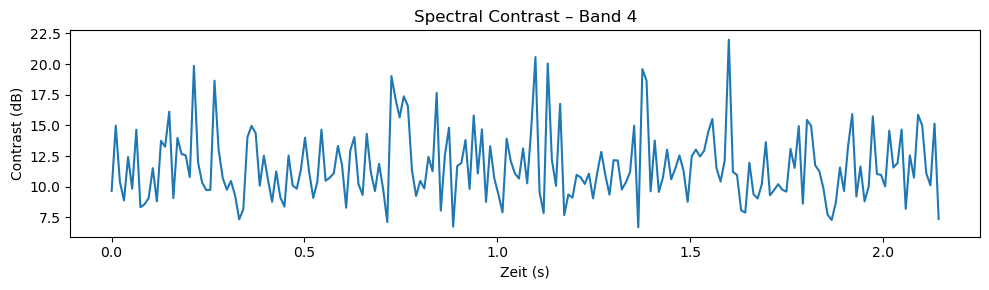

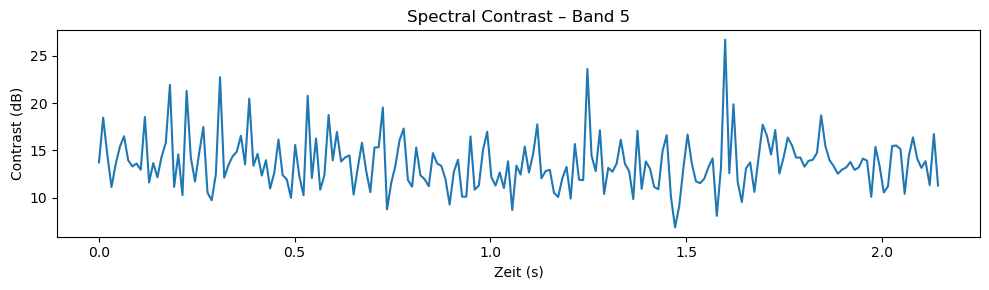

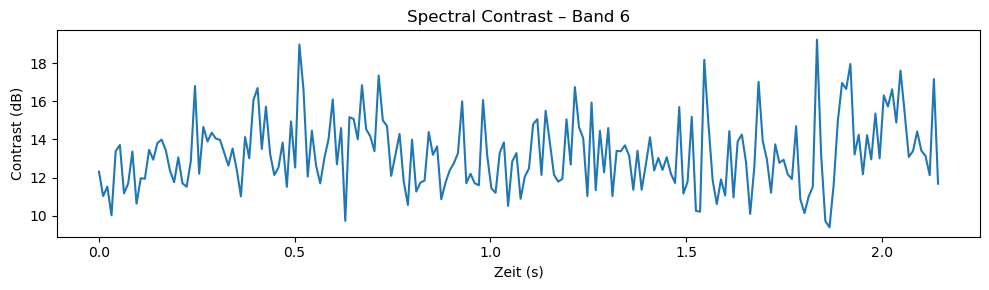

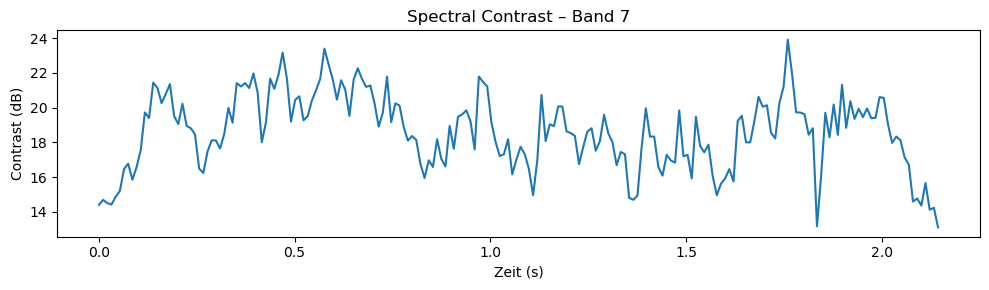

In [209]:
import librosa, librosa.display
import numpy as np
import matplotlib.pyplot as plt

contrast = librosa.feature.spectral_contrast(S=S_mag, sr=sr, n_bands=6)
t_contrast = librosa.times_like(contrast, sr=sr, hop_length=HOP_LENGTH)

for i in range(contrast.shape[0]):
    plt.figure(figsize=(10,3))
    plt.plot(t_contrast, contrast[i])
    plt.xlabel("Zeit (s)")
    plt.ylabel("Contrast (dB)")
    plt.title(f"Spectral Contrast – Band {i+1}")
    plt.tight_layout()
    plt.show()


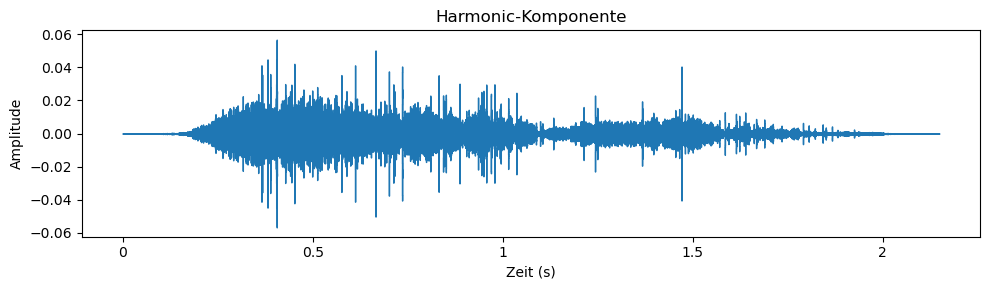

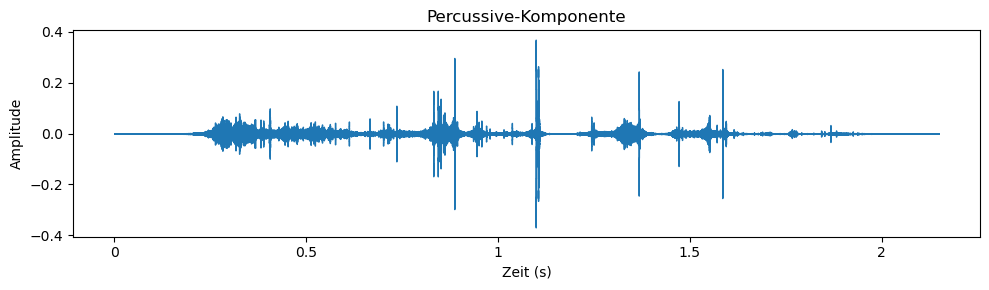

Harmonic-Anteil: 14.1%  |  Percussive-Anteil: 85.9%


In [211]:
import librosa.display

# Separation via Medianfilterung der STFT
y_harm, y_perc = librosa.effects.hpss(y)

# Hüllkurven
t = np.arange(len(y))/sr
plt.figure(figsize=(10,3))
librosa.display.waveshow(y_harm, sr=sr)
plt.title("Harmonic-Komponente")
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
librosa.display.waveshow(y_perc, sr=sr)
plt.title("Percussive-Komponente")
plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Prozentuale Energieanteile
E_harm = np.sum(y_harm**2)
E_perc = np.sum(y_perc**2)
share_harm = E_harm / (E_harm + E_perc)
share_perc = E_perc / (E_harm + E_perc)
print(f"Harmonic-Anteil: {share_harm*100:.1f}%  |  Percussive-Anteil: {share_perc*100:.1f}%")


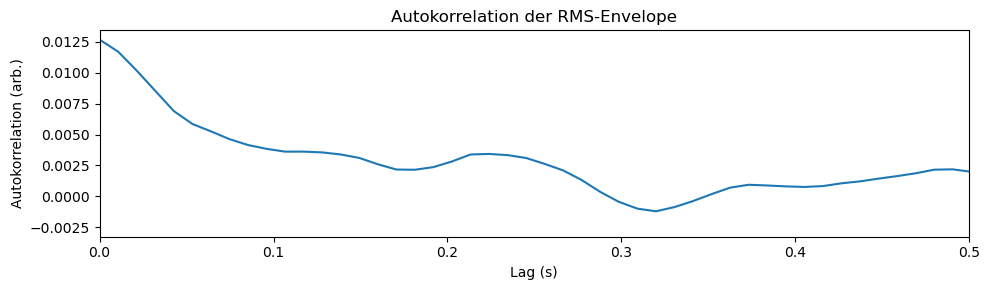

In [213]:
# RMS (Frame-basiert)
rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP_LENGTH)[0]
rms = rms - np.mean(rms)
autocorr = np.correlate(rms, rms, mode='full')
autocorr = autocorr[autocorr.size//2:]  # nur positive Lags
lags = np.arange(len(autocorr)) * (HOP_LENGTH / sr)

plt.figure(figsize=(10,3))
plt.plot(lags, autocorr)
plt.xlim(0, 0.5)  # bis 500 ms reicht
plt.xlabel("Lag (s)")
plt.ylabel("Autokorrelation (arb.)")
plt.title("Autokorrelation der RMS-Envelope")
plt.tight_layout()
plt.show()



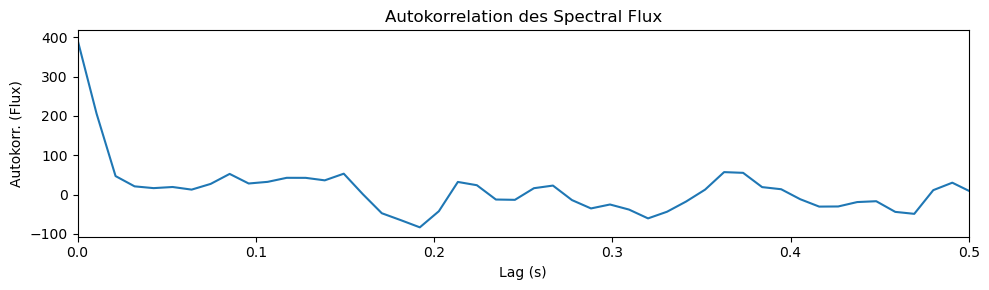

In [215]:
import matplotlib.pyplot as plt
import numpy as np

spec_flux = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP_LENGTH)
spec_autocorr = np.correlate(spec_flux - np.mean(spec_flux), spec_flux - np.mean(spec_flux), mode='full')
spec_autocorr = spec_autocorr[spec_autocorr.size//2:]
lags = np.arange(len(spec_autocorr)) * (HOP_LENGTH / sr)

plt.figure(figsize=(10,3))
plt.plot(lags, spec_autocorr)
plt.xlim(0,0.5)
plt.xlabel("Lag (s)")
plt.ylabel("Autokorr. (Flux)")
plt.title("Autokorrelation des Spectral Flux")
plt.tight_layout()
plt.show()


In [217]:
import numpy as np, librosa

# Sicherstellen, dass S_mag existiert
try:
    S_mag
except NameError:
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, window=WIN)
    S_mag = np.abs(S)

# Spectral Contrast berechnen
contrast = librosa.feature.spectral_contrast(S=S_mag, sr=sr, n_bands=6)  # shape: (7, frames)
t_contrast = librosa.times_like(contrast, sr=sr, hop_length=HOP_LENGTH)

def stats(x):
    return dict(mean=float(np.nanmean(x)),
                p10=float(np.nanpercentile(x,10)),
                p50=float(np.nanpercentile(x,50)),
                p90=float(np.nanpercentile(x,90)))

print("=== Spectral Contrast (dB) – Zusammenfassung ===")
band_stats = []
for i in range(contrast.shape[0]):
    st = stats(contrast[i])
    band_stats.append(st)
    print(f"Band {i+1}: mean={st['mean']:.1f} dB | p10={st['p10']:.1f} | p50={st['p50']:.1f} | p90={st['p90']:.1f}")

overall_mean = float(np.nanmean(contrast))
print(f"\nGesamt-Mittelwert über alle Bänder/Frames: {overall_mean:.1f} dB")

# Optional: einfache Klassifikation als Hilfe
if overall_mean < 8:
    hint = "sehr rauschdominiert / wenig Resonanz"
elif overall_mean < 14:
    hint = "gemischt: moderater Rauschanteil mit etwas Resonanz"
else:
    hint = "deutlich resonanter / tonaler"
print("Eindruck:", hint)


=== Spectral Contrast (dB) – Zusammenfassung ===
Band 1: mean=19.3 dB | p10=13.4 | p50=18.2 | p90=26.5
Band 2: mean=7.7 dB | p10=4.1 | p50=7.3 | p90=11.9
Band 3: mean=10.3 dB | p10=7.1 | p50=9.9 | p90=14.1
Band 4: mean=11.7 dB | p10=8.7 | p50=11.1 | p90=15.4
Band 5: mean=13.7 dB | p10=10.4 | p50=13.4 | p90=17.0
Band 6: mean=13.3 dB | p10=11.0 | p50=13.1 | p90=16.0
Band 7: mean=18.6 dB | p10=15.8 | p50=18.7 | p90=21.4

Gesamt-Mittelwert über alle Bänder/Frames: 13.5 dB
Eindruck: gemischt: moderater Rauschanteil mit etwas Resonanz
